In [7]:
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = "./data"

# ── Load embeddings ────────────────────────────────────────────────────────────
with open(f"{DATA_DIR}/embeddings/genre_embeddings.json") as f:
    raw = json.load(f)

genres    = list(raw.keys())
token2idx = {g: i for i, g in enumerate(genres)}
Z         = np.array(list(raw.values()), dtype=np.float32)
Z_norm    = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)

# ── Anchors ────────────────────────────────────────────────────────────────────
ANCHORS = {
    "death metal":    np.array([20,  10,  30],  dtype=np.float32),
    "black metal":    np.array([10,  10,  10],  dtype=np.float32),
    "pop":            np.array([255, 105, 180],  dtype=np.float32),
    "jazz":           np.array([180, 120, 40],   dtype=np.float32),
    "classical":      np.array([200, 200, 255],  dtype=np.float32),
    "edm":            np.array([0,   255, 200],  dtype=np.float32),
    "tropical house": np.array([255, 200, 50],   dtype=np.float32),
    "blues":          np.array([30,  80,  180],  dtype=np.float32),
    "folk":           np.array([120, 180, 80],   dtype=np.float32),
    "reggaeton":      np.array([255, 80,  50],   dtype=np.float32),
    "house":          np.array([100, 0,   255],  dtype=np.float32),
    "rap":            np.array([50,  50,  50],   dtype=np.float32),
    "country":        np.array([210, 140, 50],   dtype=np.float32),
    "r&b":            np.array([150, 0,   100],  dtype=np.float32),
    "soul":           np.array([200, 80,  20],   dtype=np.float32),
}

anchor_keys   = [k for k in ANCHORS if k in token2idx]
anchor_idx    = np.array([token2idx[k] for k in anchor_keys])
anchor_vecs   = Z_norm[anchor_idx]
anchor_colors = np.array([ANCHORS[k] for k in anchor_keys])

print(f"Loaded {len(genres)} genres, {len(anchor_keys)}/{len(ANCHORS)} anchors found")

# ── Core functions ─────────────────────────────────────────────────────────────
def search_genres(query):
    """find available genres matching a search term"""
    matches = [g for g in genres if query.lower() in g.lower()]
    return matches[:10]

def genre_to_rgb(genre_name):
    token = genre_name.lower().strip()
    if token not in token2idx:
        close = search_genres(genre_name)
        print(f"  '{genre_name}' not found.")
        print(f"  did you mean: {close}")
        return None
    q       = Z_norm[token2idx[token]]
    sims    = anchor_vecs @ q
    sims    = sims - sims.max()
    weights = np.exp(sims * 5)
    weights /= weights.sum()
    return np.clip((weights[:, None] * anchor_colors).sum(0), 0, 255).astype(np.uint8)

def generate_blob(genre_name, size=400):
    rgb = genre_to_rgb(genre_name)
    if rgb is None:
        return None, None

    r, g, b = int(rgb[0]), int(rgb[1]), int(rgb[2])
    cx, cy  = size // 2, size // 2
    radius  = size // 2.5

    y_grid, x_grid = np.mgrid[0:size, 0:size]
    dist    = np.sqrt((x_grid - cx)**2 + (y_grid - cy)**2)
    t       = np.clip(dist / radius, 0, 1)
    falloff = 1 - t

    bg = np.array([15, 15, 15])
    fg = np.array([r,  g,  b])

    canvas = np.stack([
        (fg[0] * falloff + bg[0] * (1 - falloff)).astype(np.uint8),
        (fg[1] * falloff + bg[1] * (1 - falloff)).astype(np.uint8),
        (fg[2] * falloff + bg[2] * (1 - falloff)).astype(np.uint8),
    ], axis=2)

    return Image.fromarray(canvas), rgb

def show(genre_name):
    img, rgb = generate_blob(genre_name)
    if img is None:
        return

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor('#0f0f0f')
    ax.set_facecolor('#0f0f0f')
    ax.imshow(img)
    ax.set_title(genre_name, color='white', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(f"RGB{tuple(rgb)}", color='#aaaaaa', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()
    print(f"RGB: {tuple(rgb)}")

def show_multi(genre_names):
    """show multiple genres side by side"""
    n         = len(genre_names)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    fig.patch.set_facecolor('#0f0f0f')
    if n == 1:
        axes = [axes]

    for ax, genre in zip(axes, genre_names):
        img, rgb = generate_blob(genre)
        ax.set_facecolor('#0f0f0f')
        if img is not None:
            ax.imshow(img)
            ax.set_title(genre, color='white', fontsize=10, fontweight='bold')
            ax.set_xlabel(f"RGB{tuple(rgb)}", color='#aaaaaa', fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    plt.show()


Loaded 1305 genres, 15/15 anchors found


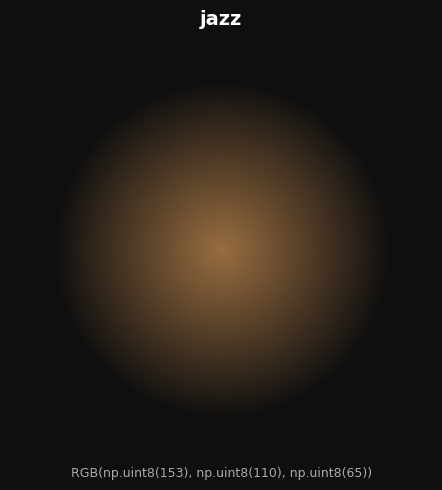

RGB: (np.uint8(153), np.uint8(110), np.uint8(65))


In [8]:
show("jazz")

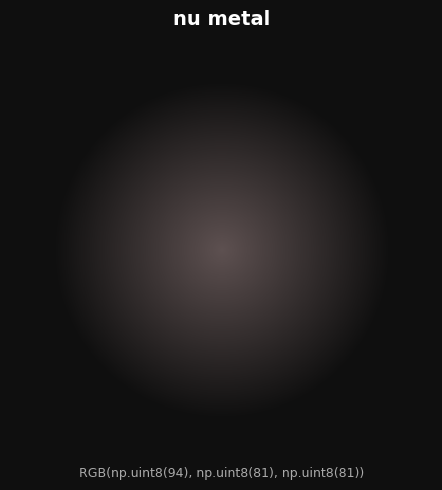

RGB: (np.uint8(94), np.uint8(81), np.uint8(81))


In [9]:
show("nu metal")

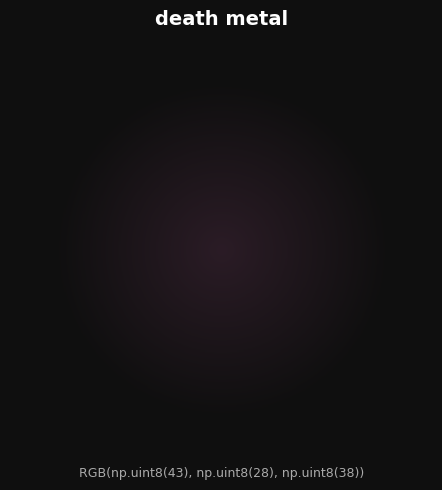

RGB: (np.uint8(43), np.uint8(28), np.uint8(38))


In [10]:
show("death metal")

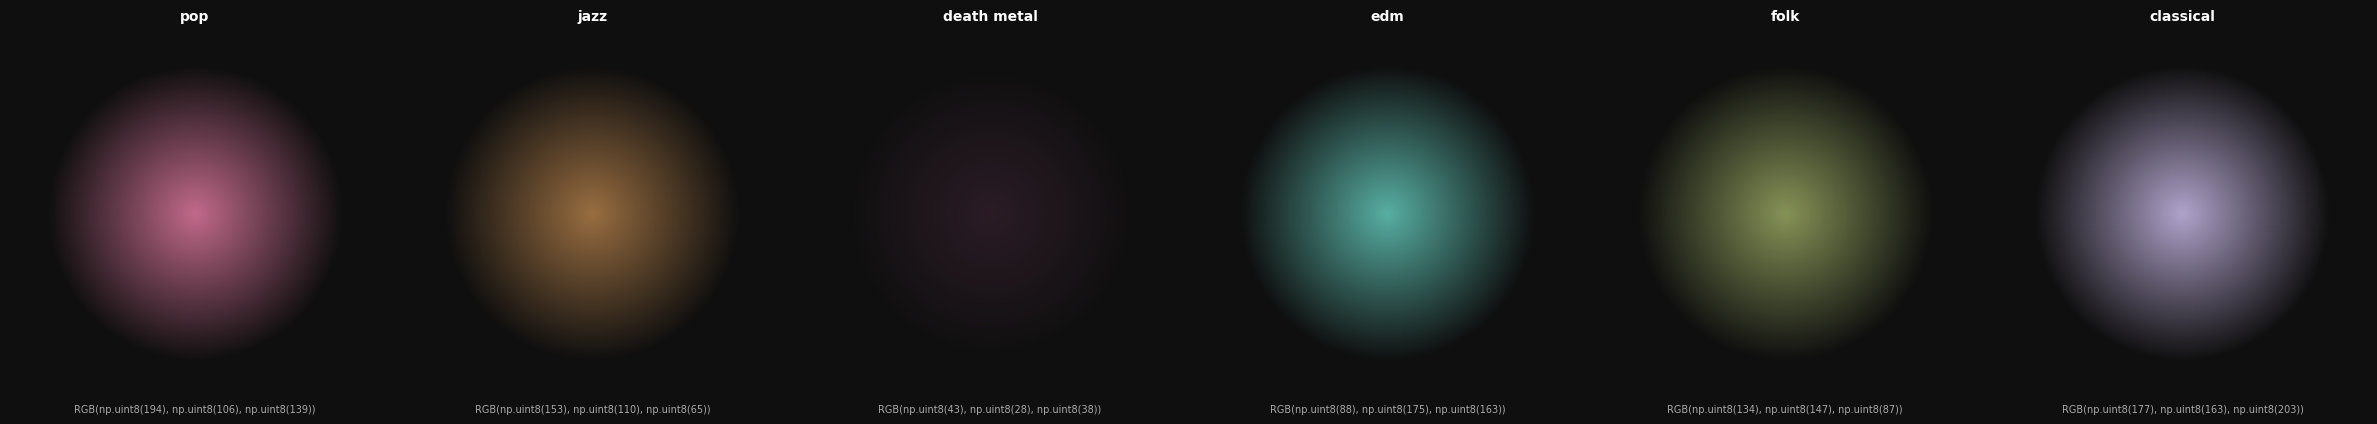

In [11]:
show_multi(["pop", "jazz", "death metal", "edm", "folk", "classical"])

In [12]:
# not sure if it's in vocab? search first
search_genres("metal")

['alternative metal',
 'alternative metalcore',
 'atmospheric black metal',
 'atmospheric post-metal',
 'avantgarde metal',
 'black metal',
 'brutal death metal',
 'canadian metal',
 'chaotic black metal',
 'christian metal']